# Bézier Curve Path Planning
This notebook demonstrates how to generate a smooth trajectory using a Cubic Bézier curve to bypass an obstacle. 

### Part 1: Setup and Libraries
First, we need to import our required Python libraries:
* **NumPy:** For efficient array handling and vector math.
* **Matplotlib:** To visually plot our trajectory, control points, and the obstacle.
* **Math:** To calculate the combinations needed for the mathematical curve.

In [1]:
# Import numpy for numerical and matrix operations
import numpy as np

# Import pyplot for creating our visualization
import matplotlib.pyplot as plt

# Import math for the combinations function used in the Bézier formula
import math

### Part 2: The Bézier Curve Algorithm
The equation we used for 4 point(cubic) Bezier curve is:

$$B(t) = (1-t)^3 P_0 + 3(1-t)^2 t P_1 + 3(1-t) t^2 P_2 + t^3 P_3$$

Basically the weighted sum of the positional vectors pointing to each control points 

Here we define the function that calculates the curve. It relies on Bernstein polynomials. The general formula for a Bézier curve of degree $n$ is:

$$B(t) = \sum_{i=0}^{n} \binom{n}{i} (1-t)^{n-i} t^i P_i$$

Where:
* $t$ represents the "time" or progress along the path, ranging from $0.0$ to $1.0$.
* $n$ is the degree of the curve (number of control points minus 1).
* $P_i$ represents the X and Y coordinates of each specific control point.

### How the Algorithm Computes the Curve
The code translates the mathematical formula into a simple three-step loop:

**1. Slicing "Time" ($t$)**
The curve's progress goes from the start ($t=0.0$) to the finish ($t=1.0$). We divide this journey into a set number of evenly spaced steps (e.g., 50 snapshots in time).

**2. Computing the Weighted Vectors**
For every snapshot of time $t$, the script loops through each control point to calculate its scaled vector. It uses the Bernstein polynomial to assign a weight to each point(essentially positional vector with a scalar that controls the length) from origin to Point $P_i$. If $t$ is small (near the start), the first points get a heavy weight, and the last points get almost zero.



**3. Adding Them Together**
We multiply each control point's $(x, y)$ coordinates by its calculated weight for that specific moment $t$. Then, we sum all those weighted coordinates together. This addition collapses the multiple pulls into one single $(x, y)$ coordinate. The script repeats this addition for all 50 snapshots, overwriting our grid of zeros with the final smooth path!

### Part 3: Path Planning Scenario
Imagine an autonomous agent is at `(0, 0)` and needs to reach `(10, 0)`. However, there is a circular obstacle blocking the direct path. 



To avoid it, we will place two intermediate control points strategically above the obstacle. The mathematical properties of the Bézier curve will "pull" the trajectory toward these points, safely arching over the obstacle.

In [2]:
def compute_bezier_points(control_points,num_points=100):
    """
    Computes the coordinates of a Bezier curve given a set of control points.
    """
    #the degree of the curve is the number of control points minus 1
    n=len(control_points)-1

    #create an array of t evenly spaced between 0 and 1
    #timestep along the curve
    t=np.linspace(0,1,num_points)

    #empty array to store the final x and y
    #store one point along the path
    curve=np.zeros((num_points,2))

    #loop through each control point to calculate its influence(positional vecotr) on the curve
    for i,p in enumerate(control_points):
        # Calculate the Bernstein polynomial for this specific point(the scalar)
        berstein=math.comb(n,i)*(1-t)**(n-i)*t**i

        #apply the weighted influence of the control point on the x axis
        curve[:,0]+=berstein*p[0]

        #apply the weighted influence of the control point on the x axis
        curve[:,1]+=berstein*p[1]

    return curve
#define the starting point
start_p=[0,0]

#define the final destination
final_p=[10,7]

#define control points to attract the curve toward them(4 points, degree of 3)
control_p1=[3,6]
control_p2=[7,8]

# Combine all points into a single NumPy array
control_points = np.array([start_p, control_p1, control_p2, final_p])

#call out function to generate 50 discrete coordinates along the trajectory(basically for each timestamp compute the point along the curve)
trajectory=compute_bezier_points(control_points,num_points=50)
# Print confirmation
print(f"Successfully generated {len(trajectory)}trajectory points. Ready for visualization!")

    


Successfully generated 50trajectory points. Ready for visualization!


### Part 4: Visualization
To confirm our math works, we will plot the environment. We'll draw the start and end points, the obstacle, the "pulling" control points (and the polygon they form), and finally, the smooth mathematical path the robot will follow.

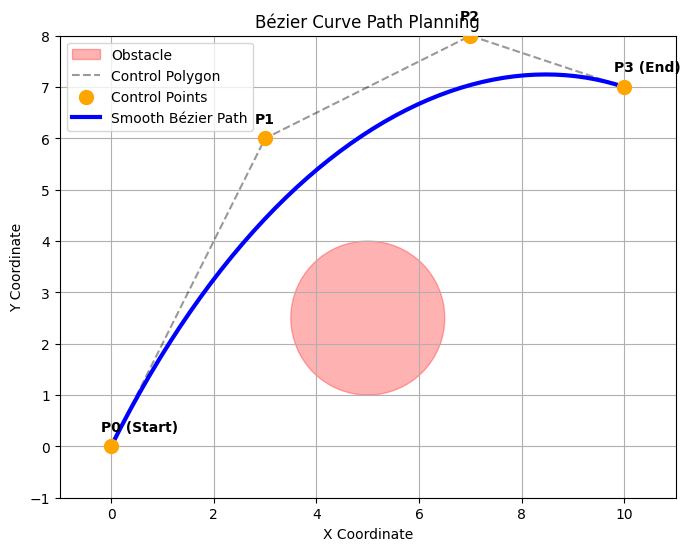

In [3]:
# Create a new figure and axis for our plot with a specific size
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Simulate the obstacle we are avoiding
# We place a red circle at (5, 2.5) with a radius of 1.5
obstacle = plt.Circle((5, 2.5), 1.5, color='red', alpha=0.3, label='Obstacle')
ax.add_patch(obstacle)

# 2. Plot the control polygon (the dashed lines connecting control points)
# This shows the rough bounding box of our curve
ax.plot(control_points[:, 0], control_points[:, 1], 'k--', alpha=0.4, label='Control Polygon')

# 3. Plot the physical control points as large orange dots
ax.scatter(control_points[:, 0], control_points[:, 1], c='orange', s=100, zorder=5, label='Control Points')

# 4. Plot the final smooth Bézier trajectory generated by our function as a solid blue line
ax.plot(trajectory[:, 0], trajectory[:, 1], 'b-', linewidth=3, label='Smooth Bézier Path')

# Add text labels next to each control point so we can see which is which
labels = ['P0 (Start)', 'P1', 'P2', 'P3 (End)']
for i, p in enumerate(control_points):
    ax.text(p[0] - 0.2, p[1] + 0.3, labels[i], fontsize=10, fontweight='bold')

# Formatting the plot: setting limits, adding a grid, and creating a legend
ax.set_xlim(-1, 11)
ax.set_ylim(-1, 8)
ax.set_aspect('equal') # Ensures our circular obstacle isn't stretched into an oval
ax.set_title('Bézier Curve Path Planning')
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.legend()
ax.grid(True)

# Display the visualization
plt.show()